# Notebook 2C: Image Annotation for Swatch/Container Recognition

This notebook prepares a sample of images for annotation in Label Studio and trains a classifier to distinguish lipstick image types: `swatch`, `bullet`, `liquid`, `closed`, and `color_not_shown`.

Image type determines the color extraction strategy: swatch images can be clustered directly; bullet images have color concentrated at the bullet tip; liquid images require isolating the wand tip; closed containers with a transparent window expose the color through a small region; images where no color is visible are flagged for fallback.

Product metadata uses keywords like "liquid", "stain", "velvet", "lacquer" as a proxy for image type, but the true label must come from visual inspection.

**Steps:**
1. Explore product name keywords to understand type distribution in the annotation sample
2. Copy the 208 annotation sample images to `data/img/annotation_sample/` for Label Studio
3. Launch Label Studio and annotate — see Annotation Guidelines in this notebook
4. Load annotations and export to `data/processed/annotations.csv`
5. *(future)* Train PyTorch classifier

# Setup

In [6]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE   = os.path.abspath('../data')
CLEAN  = os.path.join(BASE, 'img', 'original_clean')
ANNOT  = os.path.join(BASE, 'img', 'annotation_sample')
DATA   = os.path.join(BASE, 'processed')

# Exploring Product Types in the Annotation Sample

Product names in the metadata contain keywords that hint at visual format — "liquid", "stain", "velvet", etc. signal a wand/tube presentation rather than a classic bullet. This is not a ground truth label, but it gives a useful prior for understanding what annotators will encounter.

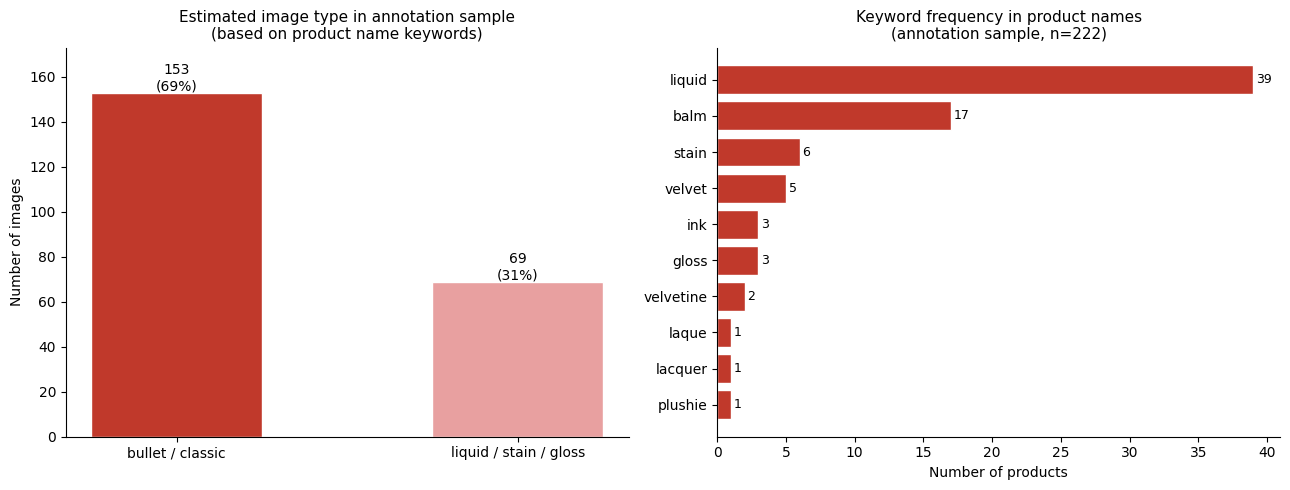


Total in sample: 222
product_type
bullet / classic          153
liquid / stain / gloss     69


In [7]:
sample   = pd.read_csv(f'{DATA}/annotation_sample.csv')
products = pd.read_csv(f'{DATA}/products_with_images.csv')
df       = sample.merge(products[['id', 'product']], on='id', how='left')

LIQUID_KEYWORDS = ['liquid', 'velvet', 'velvetine', 'plushie', 'fluid',
                   'stain', 'lacquer', 'laque', 'gloss', 'balm', 'ink', 'laquer']

def keyword_type(product_name):
    name = str(product_name).lower()
    return 'liquid / stain / gloss' if any(k in name for k in LIQUID_KEYWORDS) else 'bullet / classic'

df['product_type'] = df['product'].apply(keyword_type)

# --- figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: high-level split
counts = df['product_type'].value_counts()
colors = ['#c0392b', '#e8a0a0']
ax1.bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
ax1.set_title('Estimated image type in annotation sample\n(based on product name keywords)', fontsize=11)
ax1.set_ylabel('Number of images')
for i, (label, val) in enumerate(counts.items()):
    ax1.text(i, val + 1, f'{val}\n({val/len(df)*100:.0f}%)', ha='center', fontsize=10)
ax1.set_ylim(0, counts.max() + 20)
ax1.spines[['top', 'right']].set_visible(False)

# Right: individual keyword frequency
keyword_counts = {}
for kw in LIQUID_KEYWORDS:
    n = df['product'].str.lower().str.contains(kw, na=False).sum()
    if n > 0:
        keyword_counts[kw] = n

kw_series = pd.Series(keyword_counts).sort_values()
ax2.barh(kw_series.index, kw_series.values, color='#c0392b', edgecolor='white')
ax2.set_title('Keyword frequency in product names\n(annotation sample, n=222)', fontsize=11)
ax2.set_xlabel('Number of products')
for i, val in enumerate(kw_series.values):
    ax2.text(val + 0.2, i, str(val), va='center', fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{DATA}/../img/product_type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTotal in sample: {len(df)}')
print(df['product_type'].value_counts().to_string())

# Copy Annotation Sample to Label Studio Folder

The 222 images from `annotation_sample.csv` are copied from `original_clean/` (all `.jpg`) into `data/img/annotation_sample/`. Point Label Studio at this folder — it contains only the images that need to be labeled.

In [8]:
os.makedirs(ANNOT, exist_ok=True)

copied, skipped, missing = 0, 0, []

for img_name in sample.img_name:
    stem = os.path.splitext(img_name)[0]
    src  = os.path.join(CLEAN, stem + '.jpg')
    dst  = os.path.join(ANNOT, stem + '.jpg')

    if os.path.exists(dst):
        skipped += 1
        continue
    if not os.path.exists(src):
        missing.append(img_name)
        continue
    shutil.copy2(src, dst)
    copied += 1

print(f'Copied:  {copied}')
print(f'Skipped (already exists): {skipped}')
print(f'Missing from original_clean: {len(missing)}')
if missing:
    for name in missing:
        print(f'  {name}')

Copied:  208
Skipped (already exists): 0
Missing from original_clean: 14
  lipstick__bodyography__lipstick__opulent_red.jpg
  lipstick__pyt_beauty__double_duty_lipstick_gloss__deja_vu.jpg
  lipstick__kvd_beauty__everlasting_liquid_lipstick__echo.jpg
  lipstick__colourpop__ultra_blotted_lip__cypress_chill.jpg
  lipstick__becca_cosmetics__ultimate_lipstick_love__taupe.jpg
  lipstick__jcat_beauty__flash_metal_metallic_matte_lip__earthbound_explorer.jpg
  lipstick__bossy_cosmetics__bullet_lipstick__experienced.png
  lipstick__bossy_cosmetics__bullet_lipstick__graceful.jpg
  lipstick__lime_crime__matte_velvetine_lipstick__marshmallow.jpg
  lipstick__nyx_professional_makeup__dazed_diffused_blurring_lip_stick__roller_disco.jpg
  lipstick__milani__amore_satin_matte_lip_creme__violet_villain.jpg
  lipstick__lime_crime__metallic_velvetine_lipstick__eclipse.jpg
  lipstick__ulta__sheer_lipstick__red_raven.jpg
  lipstick__dose_of_colors__liquid_matte_lipstick__kiss_of_fire.jpg


14 of the 222 sampled images are missing from `original_clean/` because they were excluded by notebook 1B: 12 are transparent placeholder images (same 40KB file served by retailer pages for out-of-stock products) and 2 are corrupted files PIL cannot open. The annotation sample is therefore **208 images**. 

# Label Studio

Install and launch Label Studio. Point the image folder at `data/img/annotation_sample/` — 208 images, all `.jpg`.

Each image is annotated with a brush label: classify the image into one of the five categories and mask the area that shows the color. See **Annotation Guidelines** below for the full label schema and decision rules.

## Annotation Guidelines

Each image receives **one label** and a **brush mask over the area that shows the color**.

---

### Labels and masking rules

**`swatch`** — A flat color swatch with no packaging.
- Use only when the image contains *exclusively* a swatch (or swatches). If a bullet or liquid product appears alongside a swatch, label the image as `bullet` or `liquid` instead.
- Mask the swatch area.
- *Edge case:* An image contained two swatches of the same shade — one matte finish, one glossy. Both swatches were masked and the image was labeled `swatch` (two regions, same label).

**`bullet`** — Classic lipstick in a tube with the bullet tip visible.
- Mask the exposed bullet tip, where the color is concentrated.
- If a swatch also appears in the image, still label `bullet` and mask the bullet tip (not the swatch).

**`liquid`** — Liquid lipstick, lip stain, lacquer, or gloss (doe-foot wand or squeeze tube).
- Mask the wand tip or the product as shown.
- If a swatch also appears in the image, still label `liquid` and mask the liquid product (not the swatch).

**`closed`** — Container is closed but has a transparent window through which the color is visible.
- Mask the transparent color-showing area (typically a rectangle on the side of the container).

**`color_not_shown`** — Container is fully closed with no color visible at all (e.g., a lip balm in an opaque tube).
- Mask the entire container.
- This label is a fallback for images where color extraction is not possible from the image alone.

---

### Priority rule

When a product image contains **both a swatch and the product**, classify by the **product type** (`bullet` or `liquid`), not `swatch`. The `swatch`-only label is reserved for images where a swatch is the sole visual element.

In [4]:
!pip install label-studio


You should consider upgrading via the '/Users/connie/dev/capstone_colors/.venv/bin/python3 -m pip install --upgrade pip' command.


In [15]:
!label-studio start

=> Database and media directory: /Users/connie/Library/Application Support/label-studio
=> Static URL is set to: /static/
=> Database and media directory: /Users/connie/Library/Application Support/label-studio
=> Static URL is set to: /static/
Read environment variables from: /Users/connie/Library/Application Support/label-studio/.env
get 'SECRET_KEY' casted as '<class 'str'>' with default ''
Starting new HTTPS connection (1): pypi.org:443
https://pypi.org:443 "GET /pypi/label-studio/json HTTP/1.1" 200 36245

   ╔══════════════════════════════════════╗
   ║                                      ║
   ║   Update available 1.13.1 → 1.23.0   ║
   ║   Run pip install -U label-studio    ║
   ║                                      ║
   ╚══════════════════════════════════════╝

/Users/connie/dev/capstone_colors/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fix

# Load Annotations

In [ ]:
import json

with open(f'{DATA}/annotations_label_studio.json') as f:
    raw = json.load(f)

records = []
for task in raw:
    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    # strip the upload hash prefix (e.g. "a8d18c1f-lipstick__...")
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name

    ann = task['annotations'][0]
    result = ann['result']
    if not result:
        continue
    # brush labels export: label is in value['brushlabels'][0]
    label = result[0]['value']['brushlabels'][0]
    records.append({'img_name': img_name, 'label': label})

annotations = pd.DataFrame(records)
annotations.to_csv(f'{DATA}/annotations.csv', index=False)

print(f'Saved {len(annotations)} annotations to data/processed/annotations.csv')
print(annotations['label'].value_counts().to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

counts = annotations['label'].value_counts()
colors_map = {'swatch': '#e8a0a0', 'bullet': '#c0392b', 'liquid': '#8b0000',
              'closed': '#d4a0c0', 'color_not_shown': '#aaa'}
bar_colors = [colors_map.get(l, '#999') for l in counts.index]

ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', width=0.5)
ax.set_title('Annotation label distribution (n=208)', fontsize=11)
ax.set_ylabel('Number of images')
for i, (label, val) in enumerate(counts.items()):
    ax.text(i, val + 0.5, f'{val}\n({val/len(annotations)*100:.0f}%)', ha='center', fontsize=9)
ax.set_ylim(0, counts.max() + 15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{DATA}/../img/annotation_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Oversampling Closed Containers

The initial annotation yielded only 6 `closed` images out of 208 — too few to train a reliable classifier. To build up this class, we oversample by identifying unannotated images that almost certainly share the same container format.

**Strategy: same-product-line matching.** Each of the 6 `closed` images belongs to a specific product line (e.g., Chanel Le Rouge Duo, BareMinerals Gen Nude Matte Liquid Lipcolor). Other shades of the same product are sold in the same packaging, so they are high-confidence `closed` candidates without requiring visual inspection.

We identified 53 such candidates across 4 product lines and drew a proportional sample of 40 images, copying them to `data/img/annotation_sample_closed/` for annotation in Label Studio.

In [12]:
CLOSED_ANNOT = os.path.join(BASE, 'img', 'annotation_sample_closed')

# Product lines already confirmed as 'closed' in the first annotation round
CLOSED_PRODUCT_LINES = [
    'gen_nude_matte_liquid_lipcolor',                           # BareMinerals — 13 unannotated shades
    'le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour',     # Chanel       — 26 unannotated shades
    'phytopigments_liquid_lip',                                 # Juice Beauty —  6 unannotated shades
    'ultra_hd_lip_mousse_hyper_matte',                         # Revlon       —  8 unannotated shades
]

products = pd.read_csv(f'{DATA}/products_with_images.csv')
products['brand']        = products['img_name'].str.split('__').str[1]
products['product_name'] = products['img_name'].str.split('__').str[2]
products['stem']         = products['img_name'].str.replace(r'\.(jpg|png|webp)$', '', regex=True)

annotated = set(annotations['img_name'].str.replace(r'\.(jpg|png|webp)$', '', regex=True))
candidates = products[
    products['product_name'].isin(CLOSED_PRODUCT_LINES) &
    ~products['stem'].isin(annotated)
].copy()

print('Candidates by product line:')
print(candidates.groupby('product_name').size().to_string())
print(f'\nTotal candidates: {len(candidates)}')

Candidates by product line:
product_name
gen_nude_matte_liquid_lipcolor                          13
le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour    26
phytopigments_liquid_lip                                 6
ultra_hd_lip_mousse_hyper_matte                          8

Total candidates: 53


In [13]:
# Proportional sample of 40 across the 4 product lines
TOTAL_SAMPLE = 40
total_candidates = len(candidates)

sampled = (
    candidates.groupby('product_name', group_keys=False)
    .apply(lambda g: g.sample(n=round(len(g) / total_candidates * TOTAL_SAMPLE), random_state=42))
)

# Adjust to exactly 40 if rounding left us short/over
deficit = TOTAL_SAMPLE - len(sampled)
if deficit > 0:
    remaining = candidates[~candidates.index.isin(sampled.index)]
    sampled = pd.concat([sampled, remaining.sample(n=deficit, random_state=42)])
elif deficit < 0:
    sampled = sampled.sample(n=TOTAL_SAMPLE, random_state=42)

print(f'Sample size: {len(sampled)}')
print(sampled.groupby('product_name').size().to_string())

Sample size: 40
product_name
gen_nude_matte_liquid_lipcolor                          10
le_rouge_duo_ultra_tenue_ultrawear_liquid_lip_colour    20
phytopigments_liquid_lip                                 5
ultra_hd_lip_mousse_hyper_matte                          5


/var/folders/x0/0hqgc7vn3ws2lx6klwmn4fj00000gn/T/ipykernel_10525/140443460.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  candidates.groupby('product_name', group_keys=False)


In [14]:
os.makedirs(CLOSED_ANNOT, exist_ok=True)

copied, skipped, missing = 0, 0, []

for img_name in sampled['img_name']:
    stem = os.path.splitext(img_name)[0]
    src  = os.path.join(CLEAN, stem + '.jpg')
    dst  = os.path.join(CLOSED_ANNOT, stem + '.jpg')

    if os.path.exists(dst):
        skipped += 1
        continue
    if not os.path.exists(src):
        missing.append(img_name)
        continue
    shutil.copy2(src, dst)
    copied += 1

print(f'Copied:  {copied}')
print(f'Skipped (already exists): {skipped}')
print(f'Missing from original_clean: {len(missing)}')
if missing:
    for name in missing:
        print(f'  {name}')

Copied:  40
Skipped (already exists): 0
Missing from original_clean: 0


# Updated Annotations: Combined Label Distribution

After annotating the 40-image closed-container batch in Label Studio, the full project was re-exported to `annotations_label_studio_closed_addition.json`. This export contains all 248 annotated images (208 original + 40 new) and supersedes the round-1 export for downstream use.

The cells below load the updated annotations, save them to `annotations_combined.csv`, and re-plot the label distribution for comparison.

In [18]:
with open(f'{DATA}/annotations_label_studio_closed_addition.json') as f:
    raw_combined = json.load(f)

records_combined = []
for task in raw_combined:
    img_path = task['data']['image']
    img_name = os.path.basename(img_path)
    img_name = img_name.split('-', 1)[-1] if '-' in img_name else img_name

    ann = task['annotations'][0]
    result = ann['result']
    if not result:
        continue
    label = result[0]['value']['brushlabels'][0]
    records_combined.append({'img_name': img_name, 'label': label})

annotations_combined = pd.DataFrame(records_combined)
annotations_combined.to_csv(f'{DATA}/annotations_combined.csv', index=False)

print(f'Saved {len(annotations_combined)} annotations to data/processed/annotations_combined.csv')
print(annotations_combined['label'].value_counts().to_string())

Saved 248 annotations to data/processed/annotations_combined.csv
label
swatch             105
bullet              61
liquid              47
closed              34
color_not_shown      1


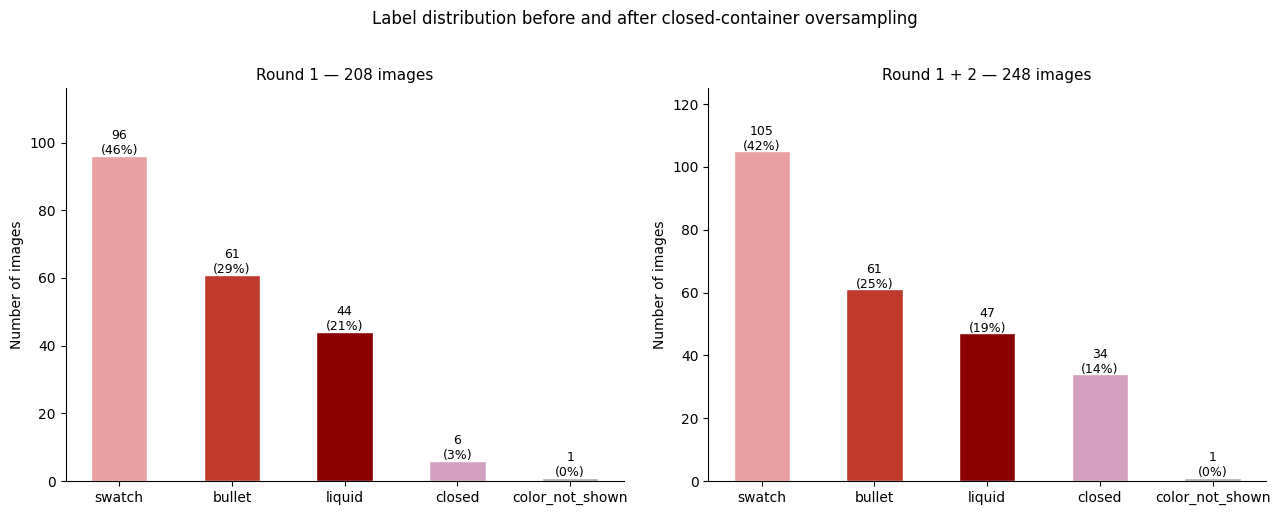

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors_map = {'swatch': '#e8a0a0', 'bullet': '#c0392b', 'liquid': '#8b0000',
              'closed': '#d4a0c0', 'color_not_shown': '#aaa'}

for ax, df, title in [
    (ax1, annotations,          'Round 1 — 208 images'),
    (ax2, annotations_combined, 'Round 1 + 2 — 248 images'),
]:
    counts = df['label'].value_counts()
    bar_colors = [colors_map.get(l, '#999') for l in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Number of images')
    for i, (label, val) in enumerate(counts.items()):
        ax.text(i, val + 0.5, f'{val}\n({val/len(df)*100:.0f}%)', ha='center', fontsize=9)
    ax.set_ylim(0, counts.max() + 20)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Label distribution before and after closed-container oversampling', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(f'{DATA}/../img/annotation_label_distribution_combined.png', dpi=150, bbox_inches='tight')
plt.show()